In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


device = torch.device("mps" if torch.cuda.is_available() else "cpu")

# Define the VAE model
class VAE(nn.Module):
    def __init__(self, z_dim=32, pose_dim=345):
        super(VAE, self).__init__()
        self.z_dim = z_dim

        # Encoder network
        self.fc1 = nn.Linear(pose_dim, 128)
        self.fc2_mu = nn.Linear(128, z_dim)  # Mean of latent space
        self.fc2_logvar = nn.Linear(128, z_dim)  # Log variance of latent space

        # Decoder network
        self.fc3 = nn.Linear(z_dim, 128)
        self.fc4 = nn.Linear(128, pose_dim)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        mu = self.fc2_mu(h1)
        logvar = self.fc2_logvar(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        # x_reconstructed = torch.sigmoid(self.fc4(h3))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar

# Loss function: VAE Loss = Reconstruction Loss + KL Divergence
def vae_loss(x_reconstructed, x, mu, logvar, beta=0.5):
    pose_dim = x.size(-1)
    reconstruction_loss = nn.functional.mse_loss(x_reconstructed, x, reduction='sum')

    # KL Divergence between the learned distribution and the prior (Gaussian)
    # D_KL(q(z|x) || p(z)) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # where mu, sigma are the mean and log-variance output by the encoder
    # and the prior is a standard normal distribution (mu=0, sigma=1)
    # The KL divergence measures how much our learned distribution differs from the prior
    # We want to minimize this difference, so the encoder outputs z's close to standard normal distribution.
    # A small KL divergence leads to better generalization.

    # Calculate the KL divergence
    # KL(q(z|x) || p(z)) = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / pose_dim
    return reconstruction_loss + beta * KL

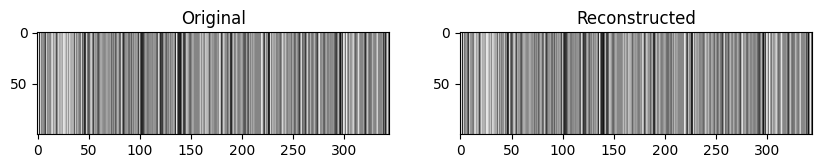

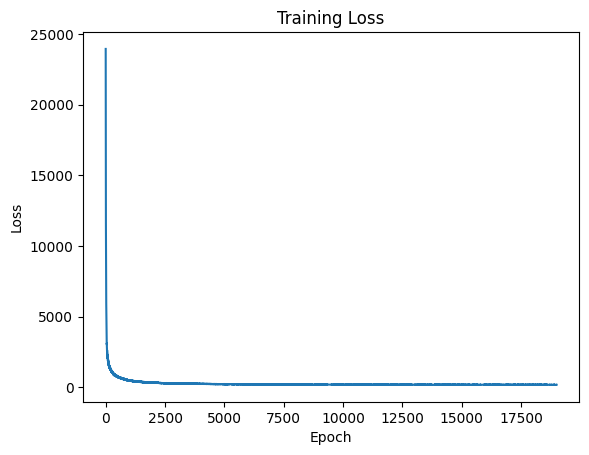

Original: -0.0665283203125, Reconstructed: -0.08800745010375977
Epoch 19/100, Loss: 2.996237167
Reshuffled dataset with new random windows


KeyboardInterrupt: 

In [9]:
from dataset.dataset import *
from IPython.display import clear_output

# Set up the data loader for MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)


pose_training_loader=DataLoader(
    ConsolidatedRAMDataset(
        consolidated_file= "dataset/genea2023_dataset/trn/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
        seq_length=1,
        seed_length=0,
        batch_size=1024,
        epoch_length=1000
    ),
    batch_size = 1,
    num_workers = 0,
    pin_memory = True
)
# Create the model, optimizer, and loss function
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

losses = []

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    pose_training_loader.dataset.reshuffle()

    for batch_idx, batch_data in enumerate(pose_training_loader):

        pose, _, _, _ = [
            item.squeeze(0).squeeze(1).to(device) for item in batch_data
        ]
        
        # pose to float # TODO: Probably dont do this
        pose = pose.float()

        optimizer.zero_grad()
        # Forward pass
        x_reconstructed, mu, logvar = model(pose)
        
        # Compute loss
        loss = vae_loss(x_reconstructed, pose, mu, logvar)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        train_loss += loss.item()
        losses.append(loss.item())

    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(pose[0].repeat(100,1).cpu().detach().numpy(), cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed")
    plt.imshow(x_reconstructed[0].repeat(100,1).cpu().detach().numpy(), cmap='gray')
    plt.show()

    # Draw the training loss
    plt.plot(losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    # As an example, print the value of the 50th pixel for both the original and reconstructed images
    print(f"Original: {pose[0][50].item()}, Reconstructed: {x_reconstructed[0][50].item()}")

    
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_loss / len(train_loader.dataset):.9f}")

# Saving the trained model
torch.save(model.state_dict(), "vae_mnist.pth")

In [4]:
# Import the viewer
import animation_visualisation
animation_visualisation.init_visualization()

Port 8000 is in use by another application. Finding alternative port...
HTTP Server running on http://localhost:8002
WebSocket server running on ws://localhost:8702


Animation viewer ready!
HTTP Server: http://localhost:8002/bvh_tests/bvh_visualisation/bvh_viewer_4.html?wsport=8702
WebSocket Server: ws://localhost:8702
Remember to click 'Start Streaming' button in the viewer.


8702

WebSocket client connected. Total connections: 1


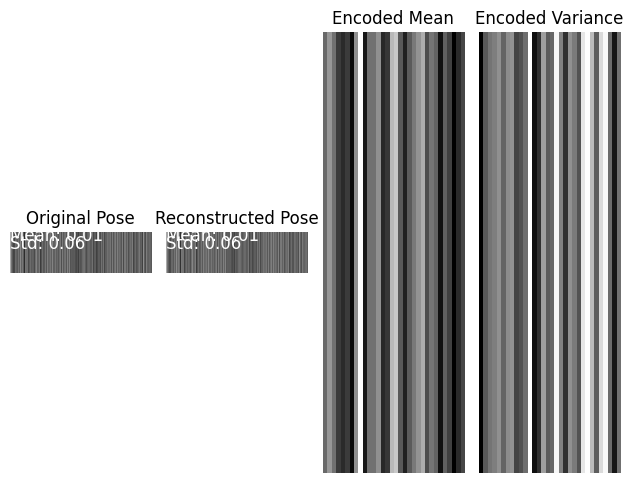

Original pose sent to viewer
Reconstructed pose sent to viewer


In [ ]:
import time
from utils.bvh_processing.bvh_converter3 import OffsetBVHParser
from IPython.display import clear_output


# Load std_pose and mean_pose from statistics.npz
statistics = np.load("dataset/genea2023_dataset/trn/main-agent/statistics.npz")
mean_pose = torch.tensor(statistics['mean_pose'].astype(np.float32)).to(device)
std_pose = torch.tensor(statistics['std_pose'].astype(np.float32)).to(device)

target_joints = ['body_world', 'b_root', 'b_r_foot', 'b_l_foot', 'b_l_upleg', 'b_l_leg', 'b_r_upleg', 'b_r_leg', 
                'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3', 'b_l_shoulder', 'b_l_arm', 'b_l_arm_twist', 
                'b_l_forearm', 'b_l_wrist_twist', 'b_l_wrist', 'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3', 'b_l_ring1', 
                'b_l_ring2', 'b_l_ring3', 'b_l_middle1', 'b_l_middle2', 'b_l_middle3', 'b_l_index1', 'b_l_index2', 
                'b_l_index3', 'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3', 'b_r_shoulder', 'b_r_arm', 
                'b_r_arm_twist', 'b_r_forearm', 'b_r_wrist_twist', 'b_r_wrist', 'b_r_thumb0', 'b_r_thumb1', 
                'b_r_thumb2', 'b_r_thumb3', 'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3', 'b_r_middle1', 'b_r_middle2', 
                'b_r_middle3', 'b_r_ring1', 'b_r_ring2', 'b_r_ring3', 'b_r_index1', 'b_r_index2', 'b_r_index3', 
                'b_neck0', 'b_head']

bvh_template = "bvh_tests/bvh/template.bvh"

# Load the BVH file and extract features
parser = OffsetBVHParser(bvh_template, target_joints)

# Visualize some results after training
# model.eval()
# with torch.no_grad():
#     sample = torch.randn(64, 20).to(device)  # Sample random z-values
#     reconstructed = model.decode(sample).cpu()

#     unnormalized_reconstructed = reconstructed * std_pose + mean_pose

#     for i in range(64):
#         # Clear the output for better visualization
#         clear_output(wait=True)

#         # Draw the reconstructed pose as an image for debugging
#         plt.imshow(unnormalized_reconstructed[i].reshape(69, 5).cpu().numpy(), cmap='gray')
#         plt.title(f"Reconstructed Pose {i + 1}")
#         plt.axis('off')
#         plt.show()

#         frame = parser.features_to_websocket_format(unnormalized_reconstructed[i].unsqueeze(0).unsqueeze(0),frame_idx=0)

#         # Send the reconstructed images to the viewer
#         animation_visualisation.send_frame(frame)
        
#         # Sleep for 2 seconds
#         time.sleep(0.5)

# I want to compare the original and reconstructed poses
# First extract 64 random poses from the dataset


with torch.no_grad():

    # Load the dataset
    dataset = ConsolidatedRAMDataset(
        consolidated_file= "dataset/genea2023_dataset/trn/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
        seq_length=1,
        seed_length=0,
        batch_size=1,
        epoch_length=64
    )

    # Get the first 64 samples from the dataset
    for i in range(64):
        pose, _, _, _ = [
            item.squeeze(0).to(device) for item in dataset[i]
        ]

        # pose to float # TODO: Probably dont do this
        pose = pose.float()

        # pass the pose through the model
        # x_reconstructed, mu, logvar = model(pose)
        x_encoded_mean, x_encoded_var = model.encode(pose)
        x_reconstructed = model.decode(x_encoded_mean)

        # let x_reconsturcted instead be a fully original pose
        # sample = torch.randn(1, 128).to(device)  # Sample random z-values
        # x_reconstructed = model.decode(sample)

        # unormalize the reconstructed pose
        x_reconstructed_unnormalized = x_reconstructed * std_pose * 10.0 + mean_pose

        # unnormalize the original pose
        pose_unnormalized = pose * std_pose  * 10.0 + mean_pose


        # Draw a picture of the original and reconstructed pose
        plt.subplot(1, 4, 1)
        plt.imshow(pose.repeat(100,1).cpu().numpy(),cmap='gray')
        plt.title("Original Pose")
        plt.axis('off')
        # Write the mean of the pose
        plt.text(0, 20, f"Mean: {pose.mean().item():.2f}", color='white', fontsize=12)
        # Write the std of the pose
        plt.text(0, 40, f"Std: {pose.std().item():.2f}", color='white', fontsize=12)

        plt.subplot(1, 4, 2)
        plt.imshow(x_reconstructed.repeat(100,1).cpu().numpy(),cmap='gray')
        plt.title("Reconstructed Pose")
        plt.axis('off')
        # Write the mean of the pose
        plt.text(0, 20, f"Mean: {x_reconstructed.mean().item():.2f}", color='white', fontsize=12)
        # Write the std of the pose
        plt.text(0, 40, f"Std: {x_reconstructed.std().item():.2f}", color='white', fontsize=12)

        # Draw the encoded mean and variance
        plt.subplot(1, 4, 3)
        plt.imshow(x_encoded_mean.repeat(10,1).cpu().numpy(),cmap='gray')
        plt.title("Encoded Mean")
        plt.axis('off')
        plt.subplot(1, 4, 4)
        plt.imshow(x_encoded_var.repeat(10,1).cpu().numpy(),cmap='gray')
        plt.title("Encoded Variance")
        plt.axis('off')
        plt.tight_layout()

        plt.show()


        # Send the original pose to the viewer
        original_frame = parser.features_to_websocket_format((pose_unnormalized).unsqueeze(0),frame_idx=0)
        animation_visualisation.send_frame(original_frame)
        animation_visualisation.send_frame(original_frame)

        print("Original pose sent to viewer")

        # wait for 1 seconds
        time.sleep(0.5)

        # Send the reconstructed pose to the viewer
        reconstructed_frame = parser.features_to_websocket_format(x_reconstructed_unnormalized.unsqueeze(0),frame_idx=0)
        animation_visualisation.send_frame(reconstructed_frame)
        animation_visualisation.send_frame(reconstructed_frame)

        print("Reconstructed pose sent to viewer")

        # wait for 3 seconds
        time.sleep(3)

        clear_output(wait=True)



In [ ]:
# Display reconstructed images
def show_reconstructed_images(model, data_loader):
    model.eval()
    with torch.no_grad():
        for data, _ in data_loader:
            data = data.to(device)
            x_reconstructed, _, _ = model(data)
            x_reconstructed = x_reconstructed.view(-1, 1, 28, 28).cpu()
            break

    fig, ax = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        ax[0, i].imshow(data[i].view(28, 28).cpu(), cmap='gray')
        ax[0, i].axis('off')
        ax[1, i].imshow(x_reconstructed[i].squeeze(), cmap='gray')
        ax[1, i].axis('off')
    plt.show()


# Show reconstructed images
show_reconstructed_images(model, train_loader)